In [81]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [82]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Asegura imports desde la raíz del repo (ajusta si tu notebook está en otra carpeta)
ROOT = Path().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float32"  # DV suele ser más estable y rápido en float32 en tu repo

torch.manual_seed(0)
if device == "cuda":
    torch.cuda.manual_seed_all(0)

print("device:", device, " dtype:", dtype, " ROOT:", ROOT)


device: cpu  dtype: float32  ROOT: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025


In [83]:
import importlib

import src.trainer.schrodinger_train as sch_train
import src.nn.DVPDESolver as dv_solver_mod

importlib.reload(sch_train)
importlib.reload(dv_solver_mod)

from src.trainer.schrodinger_train import train
from src.nn.DVPDESolver import DVPDESolver

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem
from src.utils.logger import Logging

print("Imports OK.")


Imports OK.


In [84]:
from src.utils.nb_run_logger import NBRunLogger
from pathlib import Path

NOTEBOOK_PATH = Path(r"./prueba_box_dv - copia.ipynb")  # <-- AJUSTA si no está en el mismo folder

run_logger = NBRunLogger("box", "DV", seed=0, tag="test")
run_logger.attach_python_logging(also_console=True)                 # <- captura los INFO:... del train
run_logger.enable_autosave_figures_each_cell()     # <- guarda figuras aunque no haya plt.show()

print("RUN_DIR:", run_logger.run_dir.resolve())
print("FIG_DIR:", run_logger.fig_dir.resolve())
print("ART_DIR:", run_logger.art_dir.resolve())


RUN_DIR: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\box\DV\20260205-104201_seed0_test
FIG_DIR: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\box\DV\20260205-104201_seed0_test\figures
ART_DIR: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\box\DV\20260205-104201_seed0_test\artifacts


In [85]:
import logging

log_path = run_logger.art_dir / "python.log"

fh = logging.FileHandler(log_path, encoding="utf-8")
fh.setLevel(logging.INFO)
fh.setFormatter(logging.Formatter("%(asctime)s %(levelname)s:%(name)s:%(message)s"))

train_lg = logging.getLogger("src.utils.logger")
# evita duplicar el file handler si ya estaba
if not any(isinstance(h, logging.FileHandler) and getattr(h, "baseFilename", "") == str(log_path) for h in train_lg.handlers):
    train_lg.addHandler(fh)

print("Logging a archivo:", log_path)


Logging a archivo: results\box\DV\20260205-104201_seed0_test\artifacts\python.log


In [86]:
# --- Pozo infinito (box) ---
eq_params = build_eq_params(
    "box",
    L=1.0,
    T=0.2,         # buen T para que Im no sea pequeña
    n_level=1,     # modo n=1
    mass=1.0,
    hbar=1.0,
    num_grid=800,  # para exact/diagnóstico
)

san = sanity_check(eq_params)
print("eq_params:", eq_params)
print("sanity:", san)


eq_params: {'example': 'box', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 50.0, 'barrier_width': 0.2, 'x_center': 0.5, 'num_grid': 800}
sanity: {'V_min': 0.0, 'V_max': 0.0, 'psi0_norm': 0.9974968671630001, 'psiT_norm': 0.9974968671630003}


In [87]:
args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "problem": "schrodinger",
    "hard_bc": True,
    "hard_bc_power": 1.0,

    # training
    "epochs": 24
    ,        # smoke razonable; sube a 1500-3000 si quieres
    "lr": 1e-3,
    "batch_size": 64,
    "print_every": 2,

    # pesos base
    "w_pde": 1.0,
    "w_bc":  0.1,        # box necesita BC fuerte (psi=0 en x=0,L)
    "w_ic":  250.0,
    "w_norm": 5.0,

    # NUEVO: ayudar a que Im no se "ignore" (generalmente mejora DV)
    "w_pde_i": 10.0,
    "w_bc_i":  1.0,
    "w_ic_i":  5.0,

    # warmup/curriculum
    "warmup_epochs": 150,
    "ic_grid": True,      # IC sobre malla (más estable)
    "N_norm": 400,
    "N_val": 400,

    # DV (circuito)
    "num_qubits": 4,
    "num_quantum_layers": 2,
    "shots": None,
    "noise": False,
    "encoding": "angle",
    "q_ansatz": "sim_circ_19",

    # red híbrida
    "classic_network": [2, 64, 2],  # input=(t,x), hidden=64, output=(Re,Im)

    # performance (MUY recomendado en DV)
    "pde_chunk_size": 64,  # chunk para residual (reduce costo / memoria)
    "l2_every": 10,         # calcula L2 cada 5 épocas (acelera)
}

logger = Logging("./results/models/checkpoints/smoke_schrodinger", "box_DV")
model = DVPDESolver(args, logger, device=torch.device(device))
model.args = args
model.draw_quantum_circuit_flag = False  # evita overhead de dibujo

print("DV model built.")


DV model built.


In [88]:
pc = run_logger.log_param_count(model)
print("Trainable params:", pc)


Trainable params: {'total': 918, 'quantum': 16, 'classical': 902}


In [89]:
run_logger.log_config(eq_params=eq_params, args=args)




In [90]:
param_dtype = next(model.parameters()).dtype
param_device = next(model.parameters()).device

t_test = torch.rand(8, 1, device=param_device, dtype=param_dtype) * eq_params["T"]
x_test = torch.rand(8, 1, device=param_device, dtype=param_dtype) * (eq_params["x_max"] - eq_params["x_min"]) + eq_params["x_min"]

y = model(torch.cat([t_test, x_test], dim=1))
print("forward ok ->", y.shape, y.dtype, y.device)


forward ok -> torch.Size([8, 2]) torch.float32 cpu


QNode encontrado en quantum_layer.circuit
0: ─╭AngleEmbedding(M0)──RX(1.52)───RZ(-0.29)─╭||─╭X──────────────╭●──────────RX(0.09)─ ···
1: ─├AngleEmbedding(M0)──RX(-0.25)──RZ(0.08)──├||─│─────╭●────────╰X──────────RX(0.70)─ ···
2: ─├AngleEmbedding(M0)──RX(-0.21)──RZ(-0.19)─├||─│──╭●─╰X─────────RX(-0.17)──RZ(-0.09) ···
3: ─╰AngleEmbedding(M0)──RX(0.78)───RZ(0.21)──╰||─╰●─╰X──RX(0.62)──RZ(0.36)──────────── ···

0: ··· ──RZ(-0.46)─╭||─╭X───────╭●─┤  <Z>
1: ··· ──RZ(-0.73)─├||─│─────╭●─╰X─┤  <Z>
2: ··· ────────────├||─│──╭●─╰X────┤  <Z>
3: ··· ────────────╰||─╰●─╰X───────┤  <Z>

M0 = 
tensor([0., 0., 0., 0.])


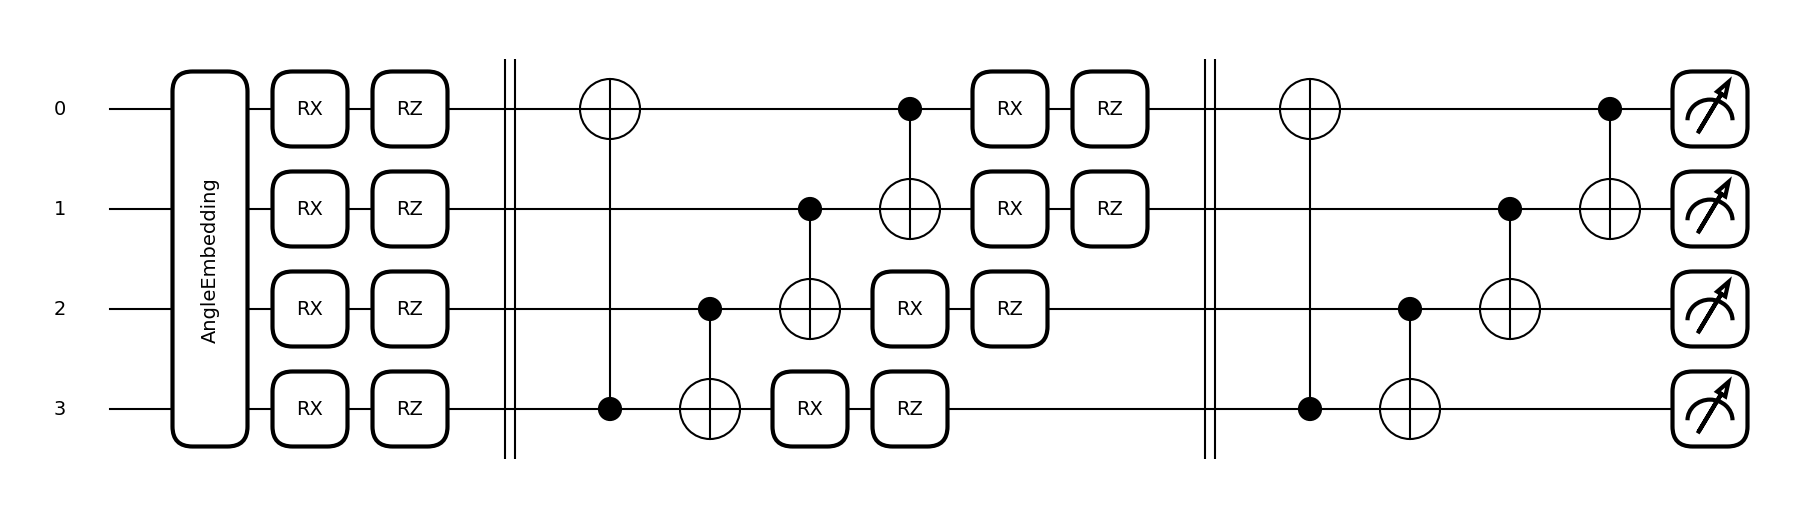

In [91]:
import torch
import pennylane as qml
import matplotlib.pyplot as plt

ql = model.quantum_layer

# Encontrar el QNode (ya viste que está en quantum_layer.circuit)
qnode = getattr(ql, "qnode", None)
if qnode is None:
    for name, val in vars(ql).items():
        if isinstance(val, qml.QNode):
            print(f"QNode encontrado en quantum_layer.{name}")
            qnode = val
            break
if qnode is None:
    raise RuntimeError("No encontré un QNode dentro de model.quantum_layer")

# Input para dibujar (ajusta longitud según tu circuito)
dev = next(model.parameters()).device
dt  = next(model.parameters()).dtype

# Prueba con 4 (tu num_qubits=4); si falla, baja a 2.
n = model.args.get("num_qubits", 4) if hasattr(model, "args") else 4
x_draw = torch.zeros(n, device=dev, dtype=dt)
if n >= 2:
    x_draw[0] = 0.0  # t
    x_draw[1] = 0.0  # x

# 1) ASCII
try:
    drawer_txt = qml.draw(qnode)     # <- sin expansion_strategy
    print(drawer_txt(x_draw))
except Exception as e:
    print("No pude dibujar en ASCII con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_txt = qml.draw(qnode)
    print(drawer_txt(x2))

# 2) Figura (matplotlib)
try:
    drawer_fig = qml.draw_mpl(qnode) # <- sin expansion_strategy
    fig, ax = drawer_fig(x_draw)
    plt.show()
except Exception as e:
    print("No pude dibujar con draw_mpl con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_fig = qml.draw_mpl(qnode)
    fig, ax = drawer_fig(x2)
    plt.show()


In [92]:
import logging, sys
from pathlib import Path

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)

    # 1) Rehabilita logging si alguien lo deshabilitó
    logging.disable(logging.NOTSET)  # equivalente a "no deshabilitar nada"

    # 2) Fuerza configuración nueva (borra handlers previos)
    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),                    # notebook live
            logging.FileHandler(log_file, encoding="utf-8"),      # a archivo
        ],
        force=True,  # <-- clave: resetea config previa
    )

    # 3) Asegura que los loggers del proyecto no bloqueen mensajes
    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False

    sys.stdout.flush()

# Usa el mismo python.log que luego parseas
force_live_logging(run_logger.art_dir / "python.log")

# test
logging.getLogger("src.utils.logger").info("TEST: ahora deberías ver esto en el notebook y guardado en python.log")



INFO:src.utils.logger:TEST: ahora deberías ver esto en el notebook y guardado en python.log


In [93]:
import logging

# Evita que src.utils.logger mande mensajes al root *y* a sus propios handlers
lg = logging.getLogger("src.utils.logger")

# 1) borra handlers que ya tuviera ese logger (si tu clase Logging le añadió FileHandler/StreamHandler)
lg.handlers.clear()

# 2) deja que SOLO el root (basicConfig) escriba a consola + archivo
lg.propagate = True
lg.disabled = False
lg.setLevel(logging.INFO)


In [94]:
# tamaños recomendados para DV (no tan grandes al inicio)
train(model, N_f=768, N_b=0, N_0=256)



INFO:src.utils.logger:It: 1, Loss: 2.138e+02, Loss_res: 2.200e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 8.359e-01, Loss_norm: 9.677e-01, Loss_gauge: 0.000e+00, w_pde: 6.67e-03, L^2_error: 8.774e-01, lr: 1.000e-03, Time: 4.35e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-05_10-42-02-354598_box_DV\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-05_10-42-02-354598_box_DV\model_weights.pth
INFO:src.utils.logger:It: 2, Loss: 2.027e+02, Loss_res: 1.903e+00,  Loss_bcs: 0.000e+00, Loss_ut_ics: 7.917e-01, Loss_norm: 9.613e-01, Loss_gauge: 0.000e+00, w_pde: 1.33e-02, L^2_error: 8.774e-01, lr: 1.000e-03, Time: 8.54e+00
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-05_10-42-02-354598_box_DV\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-05_10-42-02-354598_box_DV\model_we

In [95]:
# 1) intenta guardar lo que exista en model.loss_history / model.l2_rel_history
meta = run_logger.log_histories(model)
print("history_meta:", meta)

# 2) esto es lo importante: extrae Loss y L^2_error del LOG REAL (INFO:... It: ...)
parsed = run_logger.parse_schrodinger_train_log()
print("Puntos parseados del log:", len(parsed["it"]))
print("Último it/loss/l2:", parsed["it"][-1], parsed["loss"][-1], parsed["l2"][-1])


history_meta: {'loss_history_len': 24, 'l2_rel_history_len': 24, 'loss_history_type': "<class 'list'>", 'l2_rel_history_type': "<class 'list'>"}
Puntos parseados del log: 13
Último it/loss/l2: 24 28.43 0.8433


In [96]:
def count_trainable_params(m):
    total = sum(p.numel() for p in m.parameters() if p.requires_grad)
    quantum = sum(p.numel() for n, p in m.named_parameters() if ("quantum_layer" in n) and p.requires_grad)
    classical = total - quantum
    return total, quantum, classical

tot, q, c = count_trainable_params(model)
print(f"Trainable params -> total: {tot} | quantum: {q} | classical: {c}")


Trainable params -> total: 918 | quantum: 16 | classical: 902


In [97]:
import torch

device_ = next(model.parameters()).device
dtype_  = next(model.parameters()).dtype
problem = build_problem(eq_params, device=device_, dtype=dtype_)

# grid en x y tiempos
x = torch.linspace(problem["x_min"], problem["x_max"], 400, device=device_, dtype=dtype_).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, float(problem["T"]))

with torch.no_grad():
    psi0 = model(torch.cat([t0, x], dim=1))
    psiT = model(torch.cat([tT, x], dim=1))

# norma (trapz)
prob0 = psi0[:,0]**2 + psi0[:,1]**2
probT = psiT[:,0]**2 + psiT[:,1]**2
norm0 = torch.trapz(prob0, x.squeeze(-1)).item()
normT = torch.trapz(probT, x.squeeze(-1)).item()

# BC: valores en bordes
xL = torch.tensor([[problem["x_min"]],[problem["x_max"]]], device=device_, dtype=dtype_)
tline = torch.linspace(0.0, float(problem["T"]), 200, device=device_, dtype=dtype_).reshape(-1,1)

with torch.no_grad():
    psi_left  = model(torch.cat([tline, torch.full_like(tline, float(problem["x_min"]))], dim=1))
    psi_right = model(torch.cat([tline, torch.full_like(tline, float(problem["x_max"]))], dim=1))

max_left  = torch.sqrt(psi_left[:,0]**2  + psi_left[:,1]**2).max().item()
max_right = torch.sqrt(psi_right[:,0]**2 + psi_right[:,1]**2).max().item()

print("Norm pred t=0:", norm0)
print("Norm pred t=T:", normT)
print("max |psi(t,x_min)|:", max_left)
print("max |psi(t,x_max)|:", max_right)


Norm pred t=0: 0.5144701600074768
Norm pred t=T: 0.5300528407096863
max |psi(t,x_min)|: 0.0
max |psi(t,x_max)|: 0.0


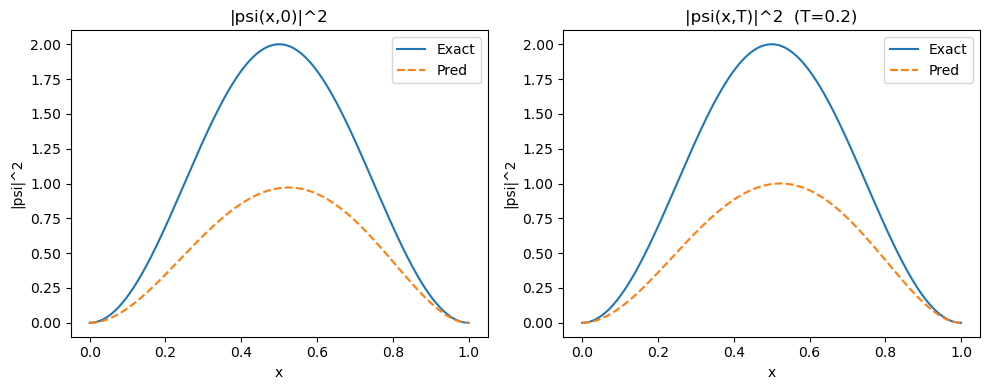

In [98]:
import numpy as np

x_plot = torch.linspace(problem["x_min"], problem["x_max"], 500, device=device_, dtype=dtype_).reshape(-1,1)
t0p = torch.zeros_like(x_plot)
tTp = torch.full_like(x_plot, float(problem["T"]))

with torch.no_grad():
    re0_ex, im0_ex, _ = problem["exact"](problem["n_level"], t0p, x_plot)
    reT_ex, imT_ex, _ = problem["exact"](problem["n_level"], tTp, x_plot)

    y0 = model(torch.cat([t0p, x_plot], dim=1))
    yT = model(torch.cat([tTp, x_plot], dim=1))

re0_pr, im0_pr = y0[:,0:1], y0[:,1:2]
reT_pr, imT_pr = yT[:,0:1], yT[:,1:2]

p0_ex = (re0_ex**2 + im0_ex**2).detach().cpu().numpy().squeeze()
p0_pr = (re0_pr**2 + im0_pr**2).detach().cpu().numpy().squeeze()
pT_ex = (reT_ex**2 + imT_ex**2).detach().cpu().numpy().squeeze()
pT_pr = (reT_pr**2 + imT_pr**2).detach().cpu().numpy().squeeze()

xx = x_plot.detach().cpu().numpy().squeeze()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(xx, p0_ex, label="Exact")
plt.plot(xx, p0_pr, "--", label="Pred")
plt.title("|psi(x,0)|^2")
plt.xlabel("x"); plt.ylabel("|psi|^2"); plt.legend()

plt.subplot(1,2,2)
plt.plot(xx, pT_ex, label="Exact")
plt.plot(xx, pT_pr, "--", label="Pred")
plt.title(f"|psi(x,T)|^2  (T={problem['T']})")
plt.xlabel("x"); plt.ylabel("|psi|^2"); plt.legend()

plt.tight_layout()
plt.show()


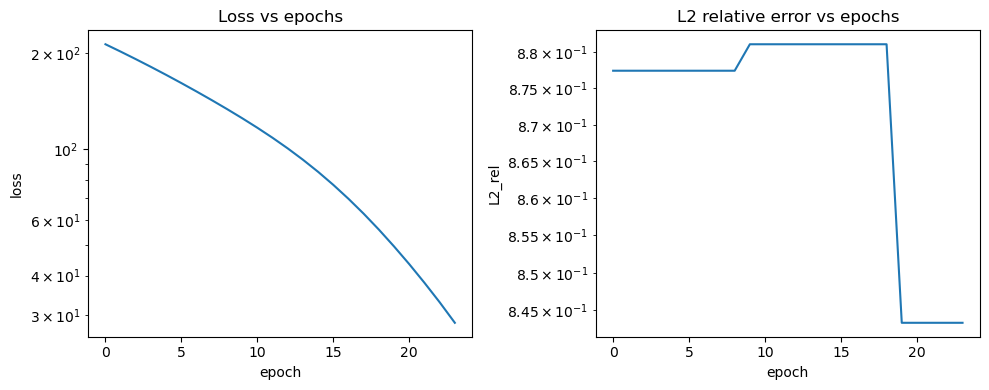

In [99]:
import numpy as np

loss_hist = np.array(getattr(model, "loss_history", []), dtype=float)
l2_hist   = np.array(getattr(model, "l2_rel_history", []), dtype=float)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(loss_hist)
plt.yscale("log")
plt.title("Loss vs epochs")
plt.xlabel("epoch"); plt.ylabel("loss")

plt.subplot(1,2,2)
plt.plot(l2_hist)
plt.yscale("log")
plt.title("L2 relative error vs epochs")
plt.xlabel("epoch"); plt.ylabel("L2_rel")

plt.tight_layout()
plt.show()


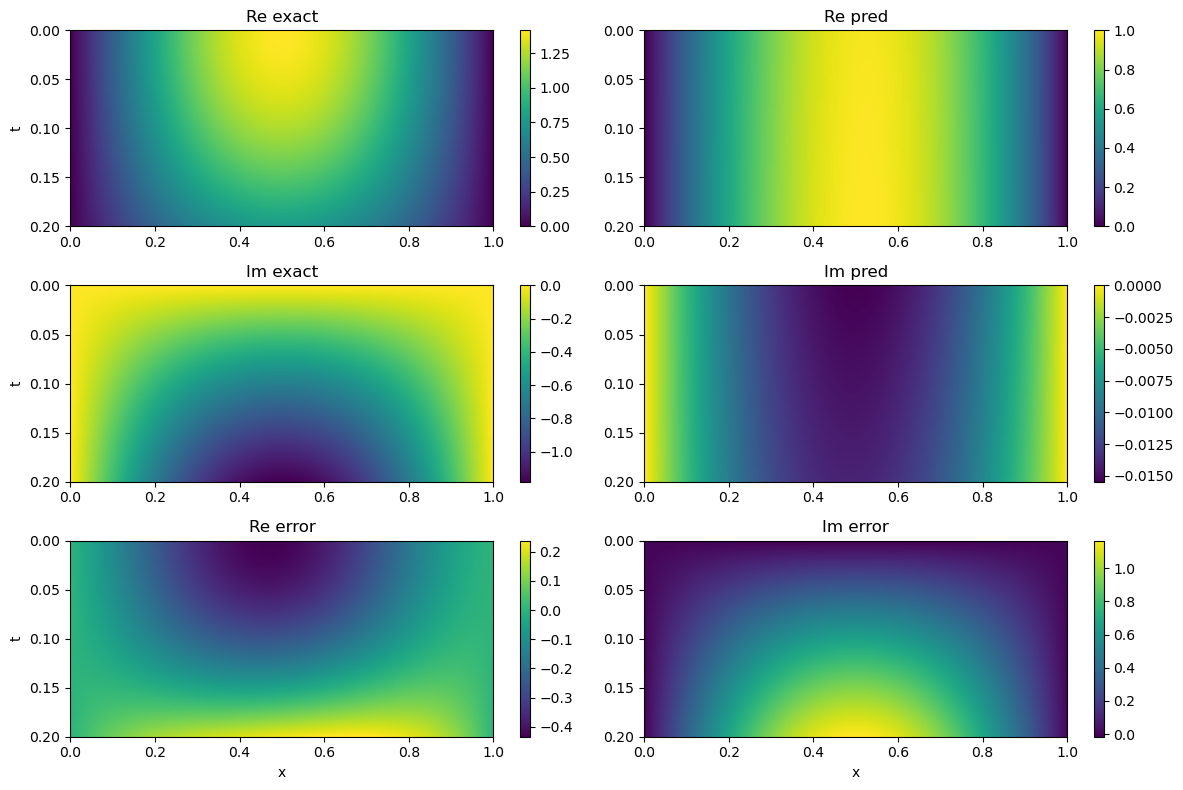

In [100]:
import numpy as np

Nt, Nx = 80, 220
t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1,1)
x_grid = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)

# mallado tipo (Nt*Nx, 1)
TT = t_grid.repeat(1, Nx).reshape(-1,1)
XX = x_grid.repeat(Nt, 1)

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], TT, XX)
    y_pr = model(torch.cat([TT, XX], dim=1))
    re_pr, im_pr = y_pr[:,0:1], y_pr[:,1:2]

re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

re_er = re_pr - re_ex
im_er = im_pr - im_ex

extent = [float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0]

plt.figure(figsize=(12,8))

plt.subplot(3,2,1); plt.imshow(re_ex, aspect="auto", extent=extent); plt.title("Re exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,2); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred");  plt.colorbar()

plt.subplot(3,2,3); plt.imshow(im_ex, aspect="auto", extent=extent); plt.title("Im exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,4); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred");  plt.colorbar()

plt.subplot(3,2,5); plt.imshow(re_er, aspect="auto", extent=extent); plt.title("Re error"); plt.xlabel("x"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,6); plt.imshow(im_er, aspect="auto", extent=extent); plt.title("Im error"); plt.xlabel("x"); plt.colorbar()

plt.tight_layout()
plt.show()


In [101]:
import logging
logging.getLogger("src.utils.logger").info("TEST: si ves esto, el logger SI está llegando al notebook")
print("TEST print visible")


INFO:src.utils.logger:TEST: si ves esto, el logger SI está llegando al notebook
TEST print visible
